#Pacotes


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

Gráficos



#Quando o APS automático não foi eficiente

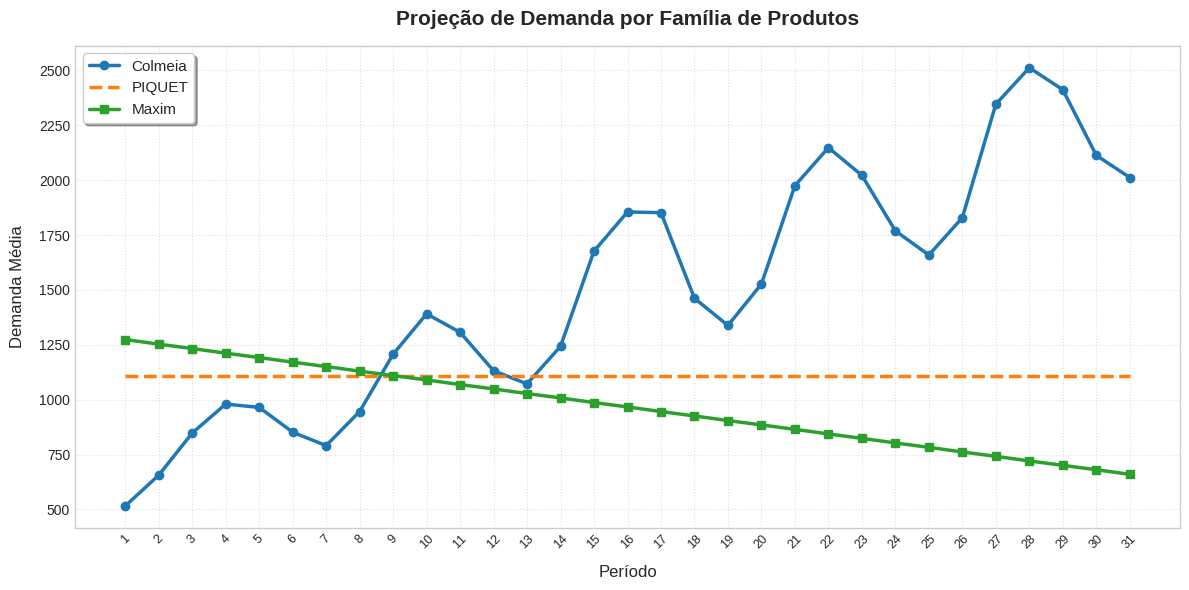

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definição dos dados estruturados (Períodos de 1 a 31)
dados = {
    'Periodo': list(range(1, 32)),
    'Colmeia': [
        516, 656, 848, 980, 965, 852, 791, 946, 1207, 1391, 1307,
        1132, 1072, 1243, 1677, 1855, 1852, 1462, 1338, 1527, 1975,
        2148, 2022, 1769, 1659, 1829, 2346, 2512, 2412, 2113, 2012
    ],
    'PIQUET': [1106] * 31,
    'Maxim': [
        1274, 1253, 1233, 1212, 1192, 1171, 1151, 1130, 1110, 1090,
        1069, 1049, 1028, 1008, 987, 967, 946, 926, 905, 885,
        865, 844, 824, 803, 783, 762, 742, 721, 701, 681, 660
    ]
}

# Criando o DataFrame do Pandas
df = pd.DataFrame(dados)

# 2. Configuração estética do gráfico
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Plotagem das curvas com cores e marcadores distintos
ax.plot(df['Periodo'], df['Colmeia'], marker='o', linewidth=2.5, label='Colmeia', color='#1f77b4')
ax.plot(df['Periodo'], df['PIQUET'], linestyle='--', linewidth=2.5, label='PIQUET', color='#ff7f0e')
ax.plot(df['Periodo'], df['Maxim'], marker='s', linewidth=2.5, label='Maxim', color='#2ca02c')

# 4. Customização de títulos e eixos
ax.set_title('Projeção de Demanda por Família de Produtos', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Período', fontsize=12, labelpad=10)
ax.set_ylabel('Demanda Média', fontsize=12, labelpad=10)

# Ajustando os marcadores do eixo X para mostrar todos os períodos de forma legível
ax.set_xticks(df['Periodo'])
ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=10)

# Adicionando uma legenda robusta e elegante
ax.legend(fontsize=11, loc='upper left', frameon=True, shadow=True, facecolor='white')

# Suavizando as linhas de grade para não carregar demais o visual
ax.grid(True, linestyle=':', alpha=0.6)

# Ajuste fino de layout para evitar cortes
plt.tight_layout()

# Exibe o gráfico no Colab
plt.show()

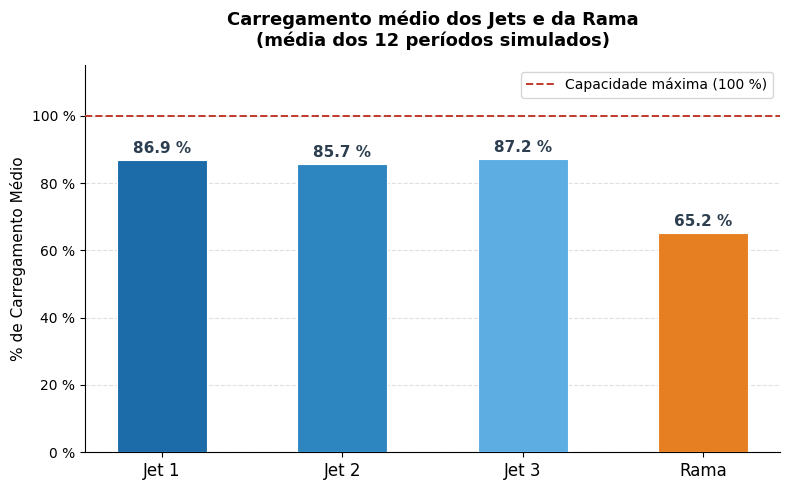

In [2]:
recursos  = ['Jet 1', 'Jet 2', 'Jet 3', 'Rama']
carga_med = [86.92,   85.74,   87.17,   65.16]   # % carga média nos 12 períodos

# ── Cores ────────────────────────────────────────────────────────────────────
cores = ['#1B6CA8', '#2E86C1', '#5DADE2', '#E67E22']

# ── Figura ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

x     = np.arange(len(recursos))
bars  = ax.bar(x, carga_med, width=0.5, color=cores, edgecolor='white',
               linewidth=0.8, zorder=3)

# Linha de referência 100 %
ax.axhline(100, color='#C0392B', linewidth=1.4, linestyle='--',
           label='Capacidade máxima (100 %)', zorder=4)

# Rótulos dentro/acima de cada barra
for bar, val in zip(bars, carga_med):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.2,
            f'{val:.1f} %',
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            color='#2C3E50')

# ── Eixos e formatação ────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(recursos, fontsize=12)
ax.set_ylabel('% de Carregamento Médio', fontsize=11)
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f} %'))
ax.set_title('Carregamento médio dos Jets e da Rama\n(média dos 12 períodos simulados)',
             fontsize=13, fontweight='bold', pad=14)

ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('grafico1_carregamento_medio.png', dpi=180, bbox_inches='tight')
plt.show()

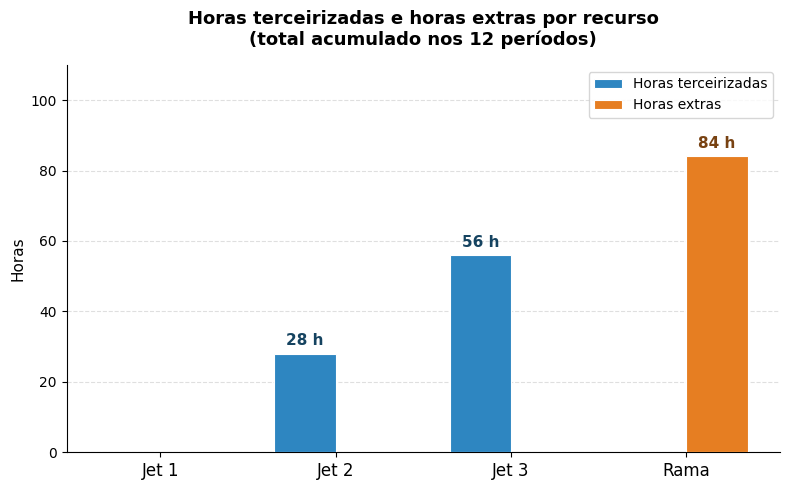

In [3]:
recursos          = ['Jet 1', 'Jet 2', 'Jet 3', 'Rama']
horas_terc        = [0,       28,      56,       0  ]
horas_extra       = [0,        0,       0,      84  ]

# ── Layout ───────────────────────────────────────────────────────────────────
x      = np.arange(len(recursos))
width  = 0.35
fig, ax = plt.subplots(figsize=(8, 5))

bars_terc  = ax.bar(x - width/2, horas_terc,  width, label='Horas terceirizadas',
                    color='#2E86C1', edgecolor='white', linewidth=0.8, zorder=3)
bars_extra = ax.bar(x + width/2, horas_extra, width, label='Horas extras',
                    color='#E67E22', edgecolor='white', linewidth=0.8, zorder=3)

# Rótulos
for bar in bars_terc:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1.5,
                f'{h:.0f} h', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#154360')

for bar in bars_extra:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1.5,
                f'{h:.0f} h', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#784212')

# ── Formatação ────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(recursos, fontsize=12)
ax.set_ylabel('Horas', fontsize=11)
ax.set_ylim(0, 110)
ax.set_title('Horas terceirizadas e horas extras por recurso\n(total acumulado nos 12 períodos)',
             fontsize=13, fontweight='bold', pad=14)

ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('grafico2_horas_extras_terc.png', dpi=180, bbox_inches='tight')
plt.show()


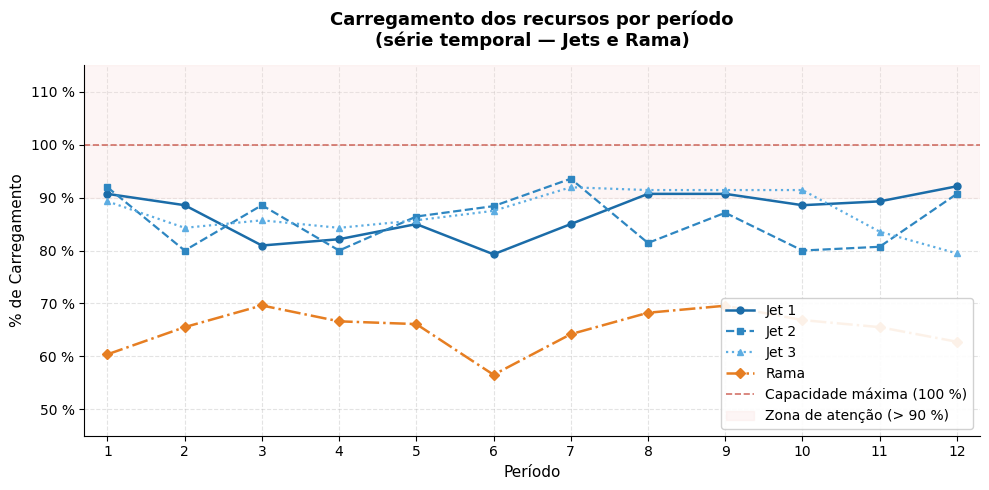

In [5]:
periodos = list(range(1, 13))   # períodos 13–24 renomeados para 1–12

carga = {
    'Jet 1': [90.71, 88.57, 80.95, 82.14, 85.00, 79.29, 85.00, 90.71,
              90.71, 88.57, 89.29, 92.14],
    'Jet 2': [91.96, 80.00, 88.57, 80.00, 86.43, 88.39, 93.57, 81.43,
              87.14, 80.00, 80.71, 90.71],
    'Jet 3': [89.29, 84.29, 85.71, 84.29, 85.71, 87.50, 91.96, 91.43,
              91.43, 91.43, 83.57, 79.46],
    'Rama' : [60.38, 65.52, 69.62, 66.62, 66.10, 56.52, 64.19, 68.24,
              69.57, 66.86, 65.52, 62.76],
}

# ── Estilos ──────────────────────────────────────────────────────────────────
estilos = {
    'Jet 1': dict(color='#1B6CA8', marker='o',  linestyle='-',  linewidth=1.8, markersize=5),
    'Jet 2': dict(color='#2E86C1', marker='s',  linestyle='--', linewidth=1.6, markersize=5),
    'Jet 3': dict(color='#5DADE2', marker='^',  linestyle=':',  linewidth=1.6, markersize=5),
    'Rama' : dict(color='#E67E22', marker='D',  linestyle='-.', linewidth=1.8, markersize=5),
}

# ── Figura ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for nome, valores in carga.items():
    ax.plot(periodos, valores, label=nome, **estilos[nome], zorder=3)

# Linha de referência 100 %
ax.axhline(100, color='#C0392B', linewidth=1.2, linestyle='--',
           alpha=0.7, label='Capacidade máxima (100 %)', zorder=2)

# Faixa de alerta (> 90 %)
ax.axhspan(90, 115, color='#FADBD8', alpha=0.25, zorder=1, label='Zona de atenção (> 90 %)')

# ── Eixos e formatação ────────────────────────────────────────────────────────
ax.set_xlabel('Período', fontsize=11)
ax.set_ylabel('% de Carregamento', fontsize=11)
ax.set_xlim(0.7, 12.3)
ax.set_ylim(45, 115)
ax.set_xticks(periodos)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v)}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f} %'))

ax.set_title('Carregamento dos recursos por período\n(série temporal — Jets e Rama)',
             fontsize=13, fontweight='bold', pad=14)

ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
ax.grid(axis='both', linestyle='--', alpha=0.35, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('grafico3_carga_temporal.png', dpi=180, bbox_inches='tight')
plt.show()

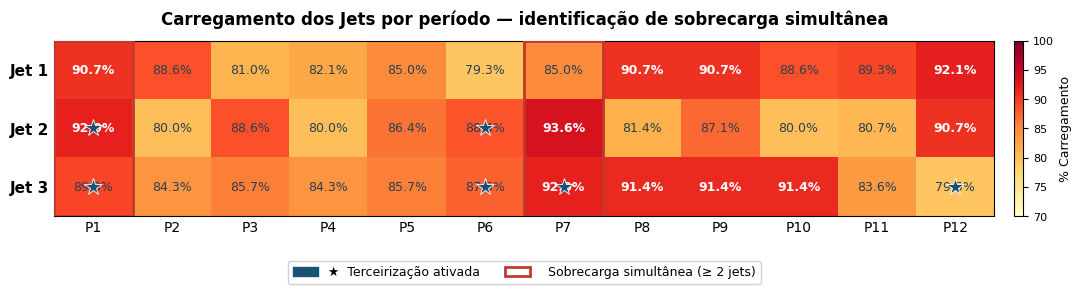

In [6]:
#HEATMAP
periodos = [f'P{i}' for i in range(1, 13)]

carga = np.array([
    # P1     P2     P3     P4     P5     P6     P7     P8     P9    P10    P11    P12
    [90.71, 88.57, 80.95, 82.14, 85.00, 79.29, 85.00, 90.71, 90.71, 88.57, 89.29, 92.14],  # Jet 1
    [91.96, 80.00, 88.57, 80.00, 86.43, 88.39, 93.57, 81.43, 87.14, 80.00, 80.71, 90.71],  # Jet 2
    [89.29, 84.29, 85.71, 84.29, 85.71, 87.50, 91.96, 91.43, 91.43, 91.43, 83.57, 79.46],  # Jet 3
])

# Células com terceirização (jet, período) — índices 0-based
terc = {
    (1, 0), (1, 5),              # Jet 2: P1, P6
    (2, 0), (2, 5), (2, 6), (2, 11),  # Jet 3: P1, P6, P7, P12
}

# ── Figura ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 3.2))

# Colormap: branco (baixo) → laranja → vermelho (alto)
cmap = plt.colormaps['YlOrRd']
im   = ax.imshow(carga, cmap=cmap, vmin=70, vmax=100, aspect='auto')

# ── Rótulos de valor em cada célula ──────────────────────────────────────────
for i in range(carga.shape[0]):
    for j in range(carga.shape[1]):
        val   = carga[i, j]
        cor   = 'white' if val >= 90 else '#2C3E50'
        peso  = 'bold'  if val >= 90 else 'normal'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=9, color=cor, fontweight=peso)

# ── Marcadores de terceirização (estrela) ────────────────────────────────────
for (i, j) in terc:
    ax.plot(j, i, marker='*', color='#1A5276', markersize=13,
            markeredgecolor='white', markeredgewidth=0.6, zorder=5)

# ── Caixas de destaque: períodos com sobrecarga simultânea (≥ 2 jets > 88%) ─
# P1: Jet1=90.71, Jet2=91.96, Jet3=89.29  → todos acima de 88%
# P7: Jet1=85.00, Jet2=93.57, Jet3=91.96  → Jet2 e Jet3 críticos
periodos_criticos = [0, 6]   # índices 0-based
for j in periodos_criticos:
    rect = plt.Rectangle((j - 0.5, -0.5), 1, carga.shape[0],
                          linewidth=2, edgecolor='#C0392B',
                          facecolor='none', zorder=6)
    ax.add_patch(rect)

# ── Eixos ────────────────────────────────────────────────────────────────────
ax.set_xticks(range(12))
ax.set_xticklabels(periodos, fontsize=10)
ax.set_yticks(range(3))
ax.set_yticklabels(['Jet 1', 'Jet 2', 'Jet 3'], fontsize=11, fontweight='bold')
ax.tick_params(length=0)

# ── Colorbar ─────────────────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, fraction=0.03)
cbar.set_label('% Carregamento', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# ── Legenda ───────────────────────────────────────────────────────────────────
star_patch  = mpatches.Patch(color='#1A5276',  label='★  Terceirização ativada')
alert_patch = mpatches.Patch(edgecolor='#C0392B', facecolor='none',
                              linewidth=2,      label='  Sobrecarga simultânea (≥ 2 jets)')
ax.legend(handles=[star_patch, alert_patch], loc='upper center',
          bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=9,
          framealpha=0.9, edgecolor='#cccccc')

# ── Título ────────────────────────────────────────────────────────────────────
ax.set_title('Carregamento dos Jets por período — identificação de sobrecarga simultânea',
             fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('grafico4_heatmap_jets.png', dpi=180, bbox_inches='tight')
plt.show()

#Resultado operacional

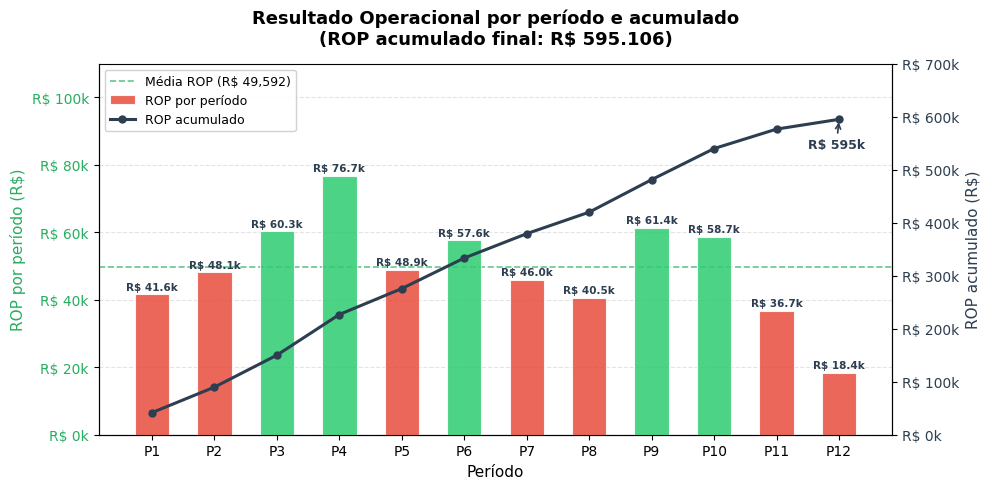

In [9]:
#ROP
periodos  = [f'P{i}' for i in range(1, 13)]
rop       = [41618.77, 48147.41, 60326.23, 76747.16, 48930.03,
             57640.66, 45981.28, 40548.34, 61374.25, 58692.36,
             36687.81, 18411.88]
rop_acum  = [41618.77,  89766.17, 150092.41, 226839.56, 275769.59,
             333410.25, 379391.53, 419939.88, 481314.13, 540006.50,
             576694.31, 595106.19]

# ── Figura com eixo duplo ─────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

x = np.arange(len(periodos))

# Barras — ROP por período
cores = ['#2ECC71' if v >= np.mean(rop) else '#E74C3C' for v in rop]
bars  = ax1.bar(x, rop, width=0.55, color=cores, alpha=0.85,
                edgecolor='white', linewidth=0.8, zorder=3, label='ROP por período')

# Linha média de ROP
media_rop = np.mean(rop)
ax1.axhline(media_rop, color='#27AE60', linewidth=1.2, linestyle='--',
            alpha=0.7, zorder=2, label=f'Média ROP (R$ {media_rop:,.0f})')

# Rótulos nas barras
for bar, val in zip(bars, rop):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 800,
             f'R$ {val/1000:.1f}k',
             ha='center', va='bottom', fontsize=7.5,
             color='#2C3E50', fontweight='bold')

# Linha — ROP acumulado (eixo direito)
ax2.plot(x, rop_acum, color='#2C3E50', linewidth=2.2, marker='o',
         markersize=5, zorder=4, label='ROP acumulado')

'''# Referência R$ 550.000 (nota 10)
ax2.axhline(550000, color='#8E44AD', linewidth=1.3, linestyle=':',
            zorder=2, label='Referência nota 10 (R$ 550k)')'''

# Anotação valor final
ax2.annotate(f'R$ {rop_acum[-1]/1000:.0f}k',
             xy=(11, rop_acum[-1]), xytext=(10.5, rop_acum[-1] - 55000),
             fontsize=9, color='#2C3E50', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.2))

# ── Eixos ─────────────────────────────────────────────────────────────────────
ax1.set_xticks(x)
ax1.set_xticklabels(periodos, fontsize=10)
ax1.set_xlabel('Período', fontsize=11)
ax1.set_ylabel('ROP por período (R$)', fontsize=11, color='#27AE60')
ax1.tick_params(axis='y', labelcolor='#27AE60')
ax1.set_ylim(0, 110000)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'R$ {v/1000:.0f}k'))

ax2.set_ylabel('ROP acumulado (R$)', fontsize=11, color='#2C3E50')
ax2.tick_params(axis='y', labelcolor='#2C3E50')
ax2.set_ylim(0, 700000)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'R$ {v/1000:.0f}k'))

ax1.grid(axis='y', linestyle='--', alpha=0.35, zorder=0)
ax1.set_axisbelow(True)
ax1.spines[['top']].set_visible(False)

# ── Legenda unificada ─────────────────────────────────────────────────────────
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2,
           loc='upper left', fontsize=9, framealpha=0.9)

ax1.set_title('Resultado Operacional por período e acumulado\n(ROP acumulado final: R$ 595.106)',
              fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('grafico5_rop.png', dpi=180, bbox_inches='tight')
plt.show()

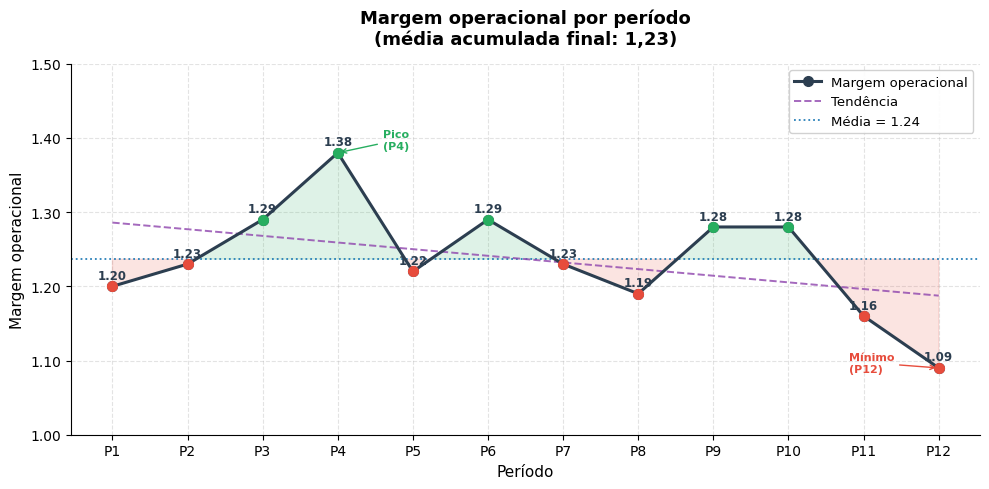

In [11]:
#margem
# ── Dados ─────────────────────────────────────────────────────────────────────
periodos = [f'P{i}' for i in range(1, 13)]
margem   = [1.20, 1.23, 1.29, 1.38, 1.22, 1.29, 1.23, 1.19, 1.28, 1.28, 1.16, 1.09]
media    = np.mean(margem)          # ≈ 1.235

x = np.arange(len(periodos))

# Linha de tendência linear
coef = np.polyfit(x, margem, 1)
trend = np.poly1d(coef)(x)

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Área sob a curva (preenchimento leve)
ax.fill_between(x, media, margem,
                where=[m >= media for m in margem],
                interpolate=True, alpha=0.15, color='#27AE60', zorder=2)
ax.fill_between(x, media, margem,
                where=[m < media for m in margem],
                interpolate=True, alpha=0.15, color='#E74C3C', zorder=2)

# Linha principal
ax.plot(x, margem, color='#2C3E50', linewidth=2.2, marker='o',
        markersize=7, zorder=4, label='Margem operacional')

# Pontos coloridos por desempenho
for i, (xi, m) in enumerate(zip(x, margem)):
    cor = '#27AE60' if m >= media else '#E74C3C'
    ax.plot(xi, m, 'o', color=cor, markersize=7, zorder=5)
    ax.text(xi, m + 0.006, f'{m:.2f}',
            ha='center', va='bottom', fontsize=8.5,
            color='#2C3E50', fontweight='bold')

# Linha de tendência
ax.plot(x, trend, color='#8E44AD', linewidth=1.4, linestyle='--',
        alpha=0.8, zorder=3,
        label=f'Tendência')

# Linha de média
ax.axhline(media, color='#2980B9', linewidth=1.3, linestyle=':',
           zorder=2, label=f'Média = {media:.2f}')

# Anotação pico e vale
ax.annotate('Pico\n(P4)',  xy=(3, 1.38), xytext=(3.6, 1.385),
            fontsize=8, color='#27AE60', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#27AE60', lw=1))
ax.annotate('Mínimo\n(P12)', xy=(11, 1.09), xytext=(9.8, 1.085),
            fontsize=8, color='#E74C3C', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1))

# ── Eixos ─────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(periodos, fontsize=10)
ax.set_xlabel('Período', fontsize=11)
ax.set_ylabel('Margem operacional', fontsize=11)
ax.set_ylim(1.00, 1.50)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}'))

ax.grid(axis='both', linestyle='--', alpha=0.35, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

ax.legend(fontsize=9.5, loc='upper right', framealpha=0.9)
ax.set_title('Margem operacional por período\n(média acumulada final: 1,23)',
             fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('grafico6_margem.png', dpi=180, bbox_inches='tight')
plt.show()

#RECEITAS

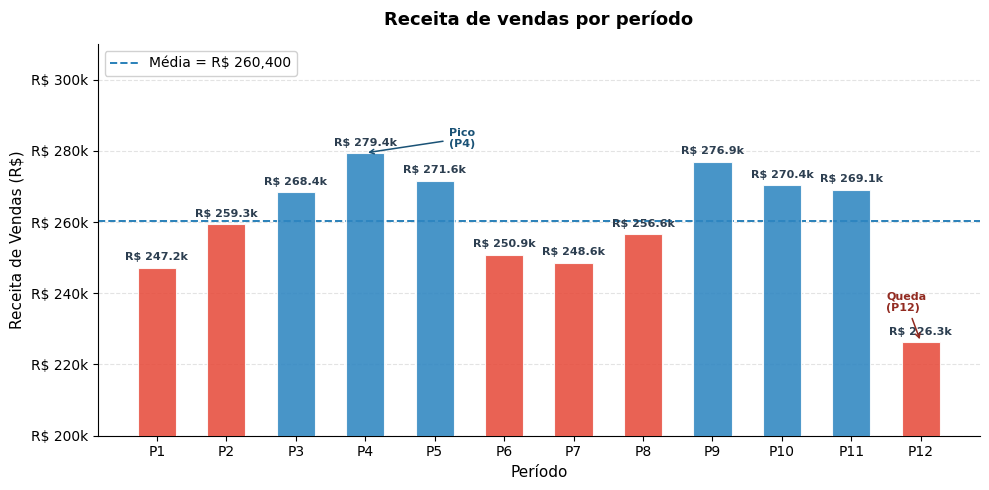

In [21]:

# ── Dados ─────────────────────────────────────────────────────────────────────
periodos     = [f'P{i}' for i in range(1, 13)]
rec_vendas   = [247225, 259325, 268425, 279400, 271600,
                250875, 248550, 256575, 276950, 270425, 269125, 226325]
media        = np.mean(rec_vendas)   # ≈ 260.400

x    = np.arange(len(periodos))
cores = ['#2E86C1' if v >= media else '#E74C3C' for v in rec_vendas]

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(x, rec_vendas, width=0.55, color=cores, alpha=0.88,
              edgecolor='white', linewidth=0.8, zorder=3)

# Linha de média
ax.axhline(media, color='#2980B9', linewidth=1.4, linestyle='--',
           zorder=2, label=f'Média = R$ {media:,.0f}')

# Rótulos
for bar, val in zip(bars, rec_vendas):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1500,
            f'R$ {val/1000:.1f}k',
            ha='center', va='bottom', fontsize=8,
            color='#2C3E50', fontweight='bold')

# Anotação pico e queda final
ax.annotate('Pico\n(P4)', xy=(3, 279400), xytext=(4.2, 281000),
            fontsize=8, color='#1A5276', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#1A5276', lw=1.1))
ax.annotate('Queda\n(P12)', xy=(11, 226325), xytext=(10.5, 235000),
            fontsize=8, color='#922B21', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#922B21', lw=1.1))

# ── Eixos ─────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(periodos, fontsize=10)
ax.set_xlabel('Período', fontsize=11)
ax.set_ylabel('Receita de Vendas (R$)', fontsize=11)
ax.set_ylim(200000, 310000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'R$ {v/1000:.0f}k'))

ax.grid(axis='y', linestyle='--', alpha=0.35, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)

ax.set_title('Receita de vendas por período',
             fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('grafico6_receita_vendas.png', dpi=180, bbox_inches='tight')
plt.show()

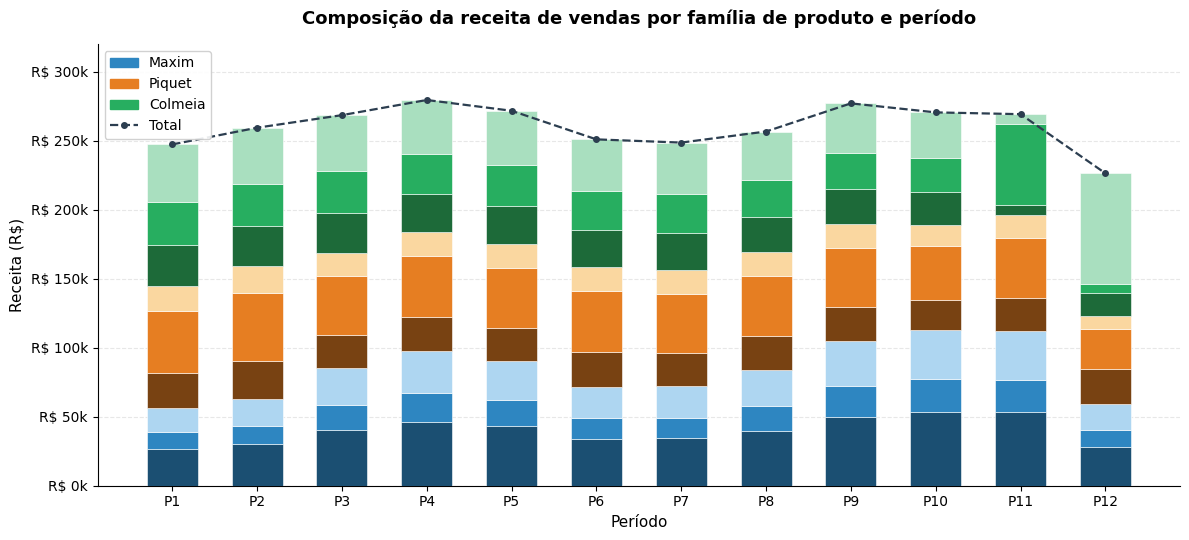

In [28]:
periodos = [f'P{i}' for i in range(1, 13)]

artigos = {
    'maxim_b' : [26750, 30000, 40500, 46500, 43000, 34000, 34250, 40000, 50000, 53500, 53250, 28250],
    'maxim_a' : [11825, 13200, 17875, 20350, 18975, 15125, 15125, 17600, 22000, 23650, 23375, 12375],
    'maxim_v' : [17600, 19800, 26675, 30800, 28325, 22550, 22550, 26400, 33000, 35475, 35200, 18700],
    'piquet_b': [25200, 27650, 23800, 24500, 24150, 24850, 24150, 24500, 24150, 21700, 24150, 25550],
    'piquet_a': [45000, 49125, 42750, 44250, 43125, 44625, 43125, 43500, 43125, 39000, 43125, 28500],
    'piquet_v': [18000, 19500, 17250, 17625, 17250, 17625, 17250, 17625, 17250, 15750, 17250,  9750],
    'colmeia_b': [29700, 28800, 28800, 27450, 27900, 26550, 26550, 25200, 25200, 23400,  6750, 16200],
    'colmeia_a': [31350, 30400, 30400, 28975, 29450, 28025, 28025, 26600, 26600, 24700, 58900,  6650],
    'colmeia_v': [41800, 40850, 40375, 38950, 39425, 37525, 37525, 35150, 35625, 33250,  7125, 80350],
}

cores = [
    '#1B4F72', '#2E86C1', '#AED6F1',  # Maxim
    '#784212', '#E67E22', '#FAD7A0',  # Piquet
    '#1D6A39', '#27AE60', '#A9DFBF',  # Colmeia
]

x     = np.arange(len(periodos))
width = 0.6

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5.5))

base = np.zeros(12)
for (nome, vals), cor in zip(artigos.items(), cores):
    ax.bar(x, np.array(vals), width, bottom=base,
           color=cor, edgecolor='white', linewidth=0.4, zorder=3)
    base += np.array(vals)

# Linha total
rec_total = [247225, 259325, 268425, 279400, 271600,
             250875, 248550, 256575, 276950, 270425, 269125, 226325]
ax.plot(x, rec_total, color='#2C3E50', linewidth=1.6, marker='o',
        markersize=4, zorder=5, linestyle='--', label='Total')

# ── Legenda simples: só 3 famílias + total ────────────────────────────────────
leg = [
    mpatches.Patch(color='#2E86C1', label='Maxim'),
    mpatches.Patch(color='#E67E22', label='Piquet'),
    mpatches.Patch(color='#27AE60', label='Colmeia'),
    plt.Line2D([0], [0], color='#2C3E50', linewidth=1.6,
               linestyle='--', marker='o', markersize=4, label='Total'),
]
ax.legend(handles=leg, fontsize=10, loc='upper left',
          framealpha=0.9, edgecolor='#cccccc')

# ── Eixos ─────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(periodos, fontsize=10)
ax.set_xlabel('Período', fontsize=11)
ax.set_ylabel('Receita (R$)', fontsize=11)
ax.set_ylim(0, 320000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'R$ {v/1000:.0f}k'))

ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

ax.set_title('Composição da receita de vendas por família de produto e período',
             fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('grafico7_receita_por_artigo.png', dpi=180, bbox_inches='tight')
plt.show()

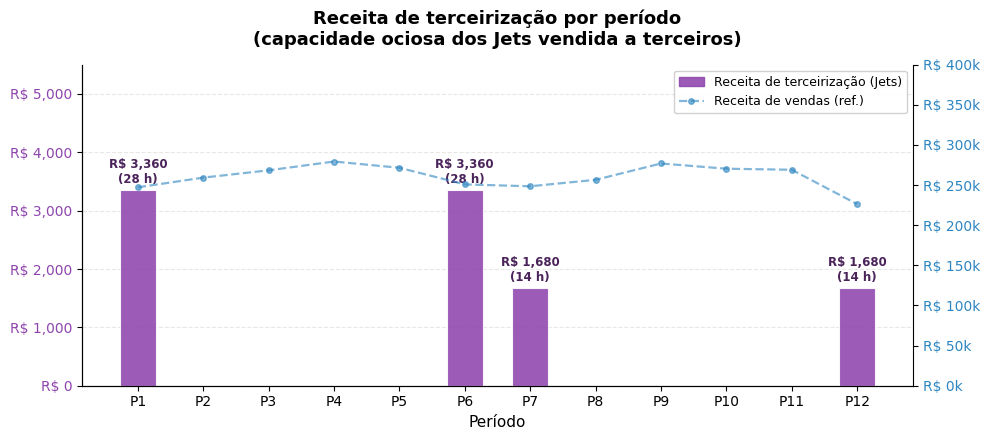

In [26]:
periodos  = [f'P{i}' for i in range(1, 13)]
rec_terc  = [3360, 0, 0, 0, 0, 3360, 1680, 0, 0, 0, 0, 1680]
horas     = [28,   0, 0, 0, 0, 28,   14,   0, 0, 0, 0, 14  ]   # horas vendidas

x     = np.arange(len(periodos))
cores = ['#8E44AD' if v > 0 else '#D5D8DC' for v in rec_terc]

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))

bars = ax.bar(x, rec_terc, width=0.55, color=cores, alpha=0.88,
              edgecolor='white', linewidth=0.8, zorder=3)

# Rótulos apenas nas barras com valor
for bar, val, h in zip(bars, rec_terc, horas):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 60,
                f'R$ {val:,.0f}\n({h} h)',
                ha='center', va='bottom', fontsize=8.5,
                color='#4A235A', fontweight='bold')

# Linha de receita de vendas (eixo secundário) para contextualizar proporção
ax2 = ax.twinx()
rec_vendas = [247225, 259325, 268425, 279400, 271600,
              250875, 248550, 256575, 276950, 270425, 269125, 226325]
ax2.plot(x, rec_vendas, color='#2E86C1', linewidth=1.6, linestyle='--',
         marker='o', markersize=4, alpha=0.6, label='Receita de vendas (ref.)')
ax2.tick_params(axis='y', labelcolor='#2E86C1')
ax2.set_ylim(0, 400000)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'R$ {v/1000:.0f}k'))
ax2.spines[['top']].set_visible(False)

# ── Eixos principais ──────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(periodos, fontsize=10)
ax.set_xlabel('Período', fontsize=11)
ax.tick_params(axis='y', labelcolor='#8E44AD')
ax.set_ylim(0, 5500)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'R$ {v:,.0f}'))

ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

# Legenda unificada
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
import matplotlib.patches as mpatches
patch_terc = mpatches.Patch(color='#8E44AD', alpha=0.88,
                             label='Receita de terceirização (Jets)')
ax.legend(handles=[patch_terc] + h2, labels=['Receita de terceirização (Jets)'] + l2,
          fontsize=9, loc='upper right', framealpha=0.9)

ax.set_title('Receita de terceirização por período\n(capacidade ociosa dos Jets vendida a terceiros)',
             fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('grafico8_receita_terceiros.png', dpi=180, bbox_inches='tight')
plt.show()

#Custos (visão geral)

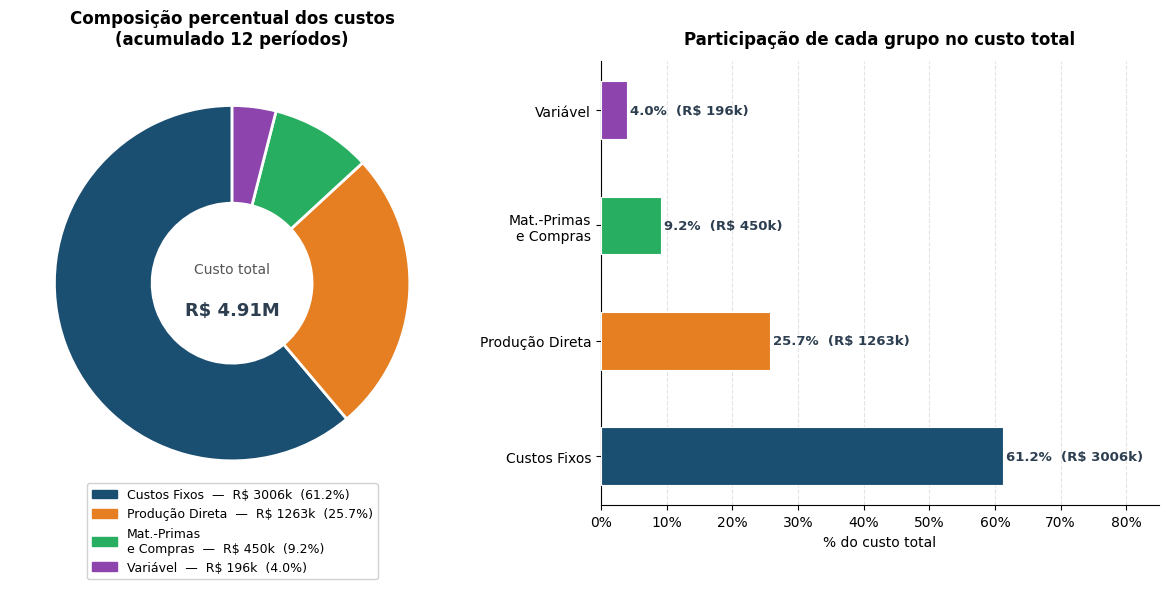

In [30]:
#custos
grupos = ['Custos Fixos', 'Produção Direta', 'Mat.-Primas\ne Compras', 'Variável']
valores = [3006000, 1262840, 450260, 195724]
cores   = ['#1B4F72', '#E67E22', '#27AE60', '#8E44AD']
total   = sum(valores)

# ── Figura: rosca + barras % lado a lado ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5),
                                gridspec_kw={'width_ratios': [1, 1.2]})

# ── Rosca ─────────────────────────────────────────────────────────────────────
wedges, texts = ax1.pie(
    valores,
    colors=cores,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.78,
)
# Texto central
ax1.text(0, 0.08, 'Custo total', ha='center', va='center',
         fontsize=10, color='#555')
ax1.text(0, -0.15, f'R$ {total/1e6:.2f}M', ha='center', va='center',
         fontsize=13, fontweight='bold', color='#2C3E50')

# Legenda externa com valores e %
legend_labels = [f'{g}  —  R$ {v/1e3:.0f}k  ({v/total*100:.1f}%)'
                 for g, v in zip(grupos, valores)]
patches = [mpatches.Patch(color=c, label=l)
           for c, l in zip(cores, legend_labels)]
ax1.legend(handles=patches, loc='lower center',
           bbox_to_anchor=(0.5, -0.18), fontsize=9,
           framealpha=0.9, edgecolor='#ccc')
ax1.set_title('Composição percentual dos custos\n(acumulado 12 períodos)',
              fontsize=12, fontweight='bold', pad=12)

# ── Barras horizontais com % ──────────────────────────────────────────────────
pcts = [v / total * 100 for v in valores]
y    = np.arange(len(grupos))

bars = ax2.barh(y, pcts, height=0.5, color=cores,
                edgecolor='white', linewidth=0.8, zorder=3)

for bar, pct, val in zip(bars, pcts, valores):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{pct:.1f}%  (R$ {val/1e3:.0f}k)',
             va='center', fontsize=9.5, color='#2C3E50', fontweight='bold')

ax2.set_yticks(y)
ax2.set_yticklabels(grupos, fontsize=10)
ax2.set_xlabel('% do custo total', fontsize=10)
ax2.set_xlim(0, 85)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax2.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
ax2.set_axisbelow(True)
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_title('Participação de cada grupo no custo total',
              fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('grafico9_pizza_custos.png', dpi=180, bbox_inches='tight')
plt.show()

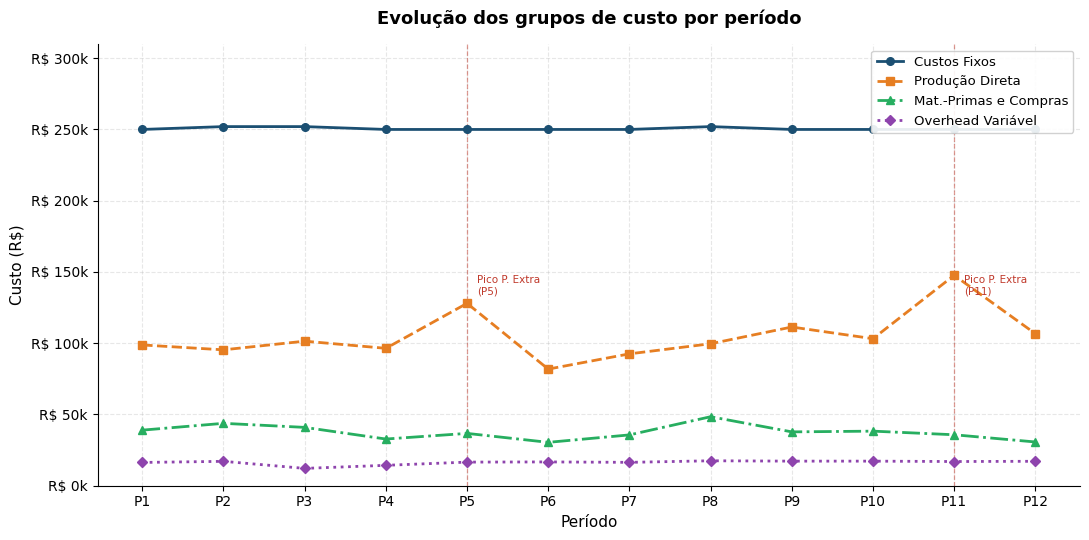

In [31]:
periodos = [f'P{i}' for i in range(1, 13)]

custos = {
    'Custos Fixos':          [250000, 252000, 252000, 250000, 250000, 250000,
                               250000, 252000, 250000, 250000, 250000, 250000],
    'Produção Direta':       [ 98775,  95350, 101435,  96415, 127980,  81840,
                                92535,  99630, 111370, 103170, 147650, 106690],
    'Mat.-Primas e Compras': [ 39000,  43780,  40940,  32760,  36720,  30440,
                                35660,  48420,  37780,  38300,  35760,  30700],
    'Overhead Variável':     [ 16329,  17113,  12161,  14315,  16570,  16704,
                                16401,  17502,  17251,  17248,  16982,  17148],
}

cores   = ['#1B4F72', '#E67E22', '#27AE60', '#8E44AD']
estilos = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'D']

x = np.arange(len(periodos))

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.5))

for (nome, vals), cor, ls, mk in zip(custos.items(), cores, estilos, markers):
    ax.plot(x, vals, color=cor, linewidth=2, linestyle=ls,
            marker=mk, markersize=5.5, label=nome, zorder=3)

# Destaque P5 e P11 — picos de produção extra
for px, label in [(4, 'Pico P. Extra\n(P5)'), (10, 'Pico P. Extra\n(P11)')]:
    ax.axvline(px, color='#C0392B', linewidth=0.9, linestyle='--', alpha=0.5, zorder=1)
    ax.text(px + 0.12, 148000, label, fontsize=7.5,
            color='#C0392B', va='top')

# ── Eixos ─────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(periodos, fontsize=10)
ax.set_xlabel('Período', fontsize=11)
ax.set_ylabel('Custo (R$)', fontsize=11)
ax.set_ylim(0, 310000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'R$ {v/1000:.0f}k'))

ax.grid(axis='both', linestyle='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9.5, loc='upper right', framealpha=0.9)

ax.set_title('Evolução dos grupos de custo por período',
             fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('grafico10_linhas_custos.png', dpi=180, bbox_inches='tight')
plt.show()

#Custos de produção

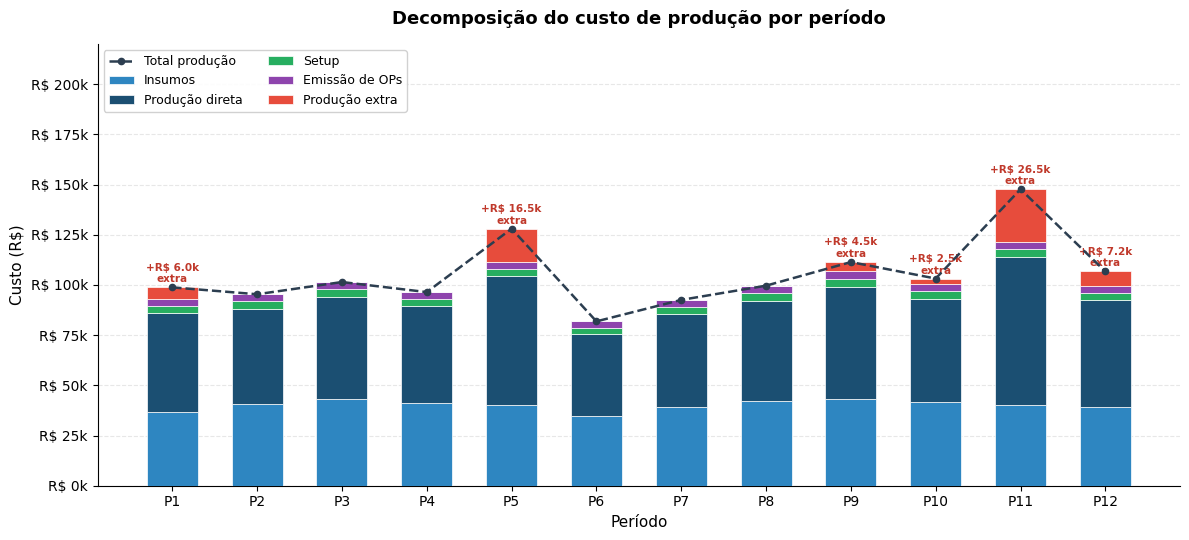

In [32]:
periodos = [f'P{i}' for i in range(1, 13)]

insumos    = [36780, 40500, 43140, 41055, 40305, 34800, 39120, 42315, 43365, 41580, 40140, 39120]
prod_dir   = [49387, 47675, 50718, 48208, 63990, 40920, 46268, 49815, 55685, 51585, 73825, 53345]
setup      = [ 3408,  3625,  3878,  3653,  3685,  3070,  3748,  3850,  4020,  3855,  3685,  3575]
emissao    = [ 3200,  3550,  3700,  3500,  3500,  3050,  3400,  3650,  3800,  3650,  3500,  3400]
prod_extra = [ 6000,     0,     0,     0, 16500,     0,     0,     0,  4500,  2500, 26500,  7250]

cores = ['#2E86C1', '#1B4F72', '#27AE60', '#8E44AD', '#E74C3C']
labels = ['Insumos', 'Produção direta', 'Setup', 'Emissão de OPs', 'Produção extra']

x     = np.arange(len(periodos))
width = 0.6

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5.5))

base = np.zeros(12)
for vals, cor, label in zip(
        [insumos, prod_dir, setup, emissao, prod_extra], cores, labels):
    ax.bar(x, vals, width, bottom=base, color=cor,
           edgecolor='white', linewidth=0.5, label=label, zorder=3)
    base += np.array(vals)

# Linha de custo total de produção
total = np.array(insumos) + np.array(prod_dir) + np.array(setup) + \
        np.array(emissao) + np.array(prod_extra)
ax.plot(x, total, color='#2C3E50', linewidth=1.8, linestyle='--',
        marker='o', markersize=4.5, zorder=5, label='Total produção')

# Anotações nos picos de produção extra
for i, pe in enumerate(prod_extra):
    if pe > 0:
        ax.text(i, total[i] + 1500,
                f'+R$ {pe/1000:.1f}k\nextra',
                ha='center', va='bottom', fontsize=7.5,
                color='#C0392B', fontweight='bold')

# ── Eixos ─────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(periodos, fontsize=10)
ax.set_xlabel('Período', fontsize=11)
ax.set_ylabel('Custo (R$)', fontsize=11)
ax.set_ylim(0, 220000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'R$ {v/1000:.0f}k'))

ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9, ncol=2)

ax.set_title('Decomposição do custo de produção por período',
             fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('grafico11_decomp_producao.png', dpi=180, bbox_inches='tight')
plt.show()

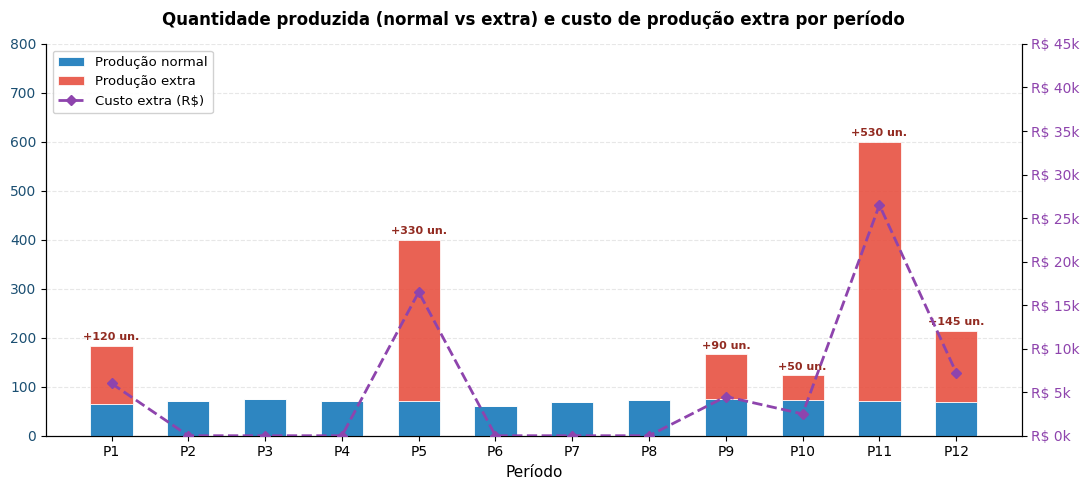

In [34]:
periodos   = [f'P{i}' for i in range(1, 13)]
qtd_normal = [64, 71, 74, 70, 70, 61, 68, 73, 76, 73, 70, 68]
qtd_extra  = [120, 0, 0, 0, 330, 0, 0, 0, 90, 50, 530, 145]

x     = np.arange(len(periodos))
width = 0.55

# ── Figura com eixo duplo ─────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

# Barras empilhadas — quantidade
b1 = ax1.bar(x, qtd_normal, width, color='#2E86C1', edgecolor='white',
             linewidth=0.6, label='Produção normal', zorder=3)
b2 = ax1.bar(x, qtd_extra,  width, bottom=qtd_normal,
             color='#E74C3C', edgecolor='white', alpha=0.88,
             linewidth=0.6, label='Produção extra', zorder=3)

# Rótulo da produção extra quando > 0
for i, (qn, qe) in enumerate(zip(qtd_normal, qtd_extra)):
    if qe > 0:
        ax1.text(i, qn + qe + 8, f'+{qe} un.',
                 ha='center', va='bottom', fontsize=8,
                 color='#922B21', fontweight='bold')

# Linha de custo de produção extra no eixo direito
custo_extra = [6000, 0, 0, 0, 16500, 0, 0, 0, 4500, 2500, 26500, 7250]
ax2.plot(x, custo_extra, color='#8E44AD', linewidth=2, linestyle='--',
         marker='D', markersize=5.5, zorder=5, label='Custo extra (R$)')

# ── Eixos ─────────────────────────────────────────────────────────────────────
ax1.set_xticks(x)
ax1.set_xticklabels(periodos, fontsize=10)
ax1.set_xlabel('Período', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#1B4F72')
ax1.set_ylim(0, 800)
ax1.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax1.set_axisbelow(True)
ax1.spines[['top']].set_visible(False)

ax2.tick_params(axis='y', labelcolor='#8E44AD')
ax2.set_ylim(0, 45000)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'R$ {v/1000:.0f}k'))
ax2.spines[['top']].set_visible(False)

# Legenda unificada
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9.5, loc='upper left', framealpha=0.9)

ax1.set_title('Quantidade produzida (normal vs extra) e custo de produção extra por período',
              fontsize=12, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('grafico12_qtd_prod_extra.png', dpi=180, bbox_inches='tight')
plt.show()

#compras emergencia

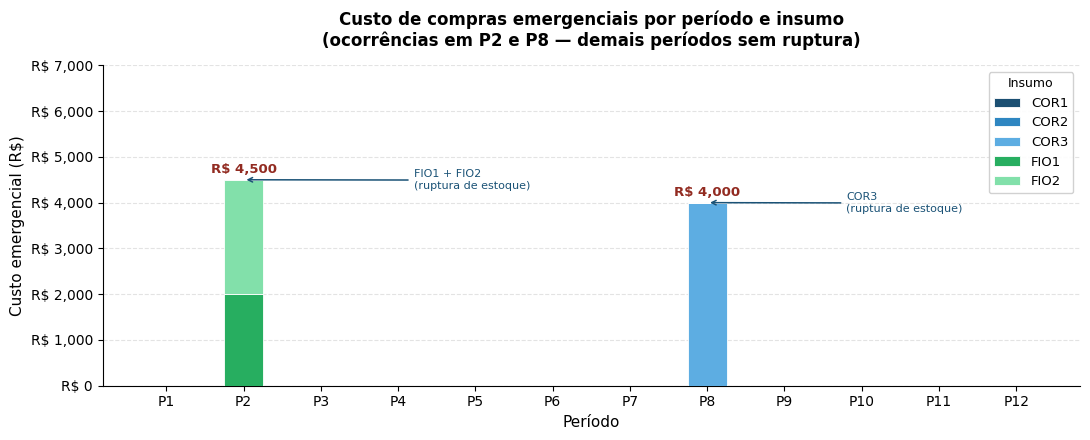

In [35]:
# Apenas P2 e P8 tiveram compras emergenciais
cor1  = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]   # COR1
cor2  = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]   # COR2
cor3  = [0, 0, 0, 0, 0, 0, 0, 4000, 0, 0, 0, 0] # COR3
fio1  = [0, 2000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] # FIO1
fio2  = [0, 2500, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] # FIO2

total = [c1+c2+c3+f1+f2 for c1,c2,c3,f1,f2 in zip(cor1,cor2,cor3,fio1,fio2)]

x     = np.arange(len(periodos))
width = 0.5

cores_insumos = ['#1B4F72', '#2E86C1', '#5DADE2', '#27AE60', '#82E0AA']
labels_ins    = ['COR1', 'COR2', 'COR3', 'FIO1', 'FIO2']

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4.5))

base = np.zeros(12)
for vals, cor, lbl in zip([cor1, cor2, cor3, fio1, fio2],
                           cores_insumos, labels_ins):
    arr = np.array(vals, dtype=float)
    ax.bar(x, arr, width, bottom=base, color=cor,
           edgecolor='white', linewidth=0.6, label=lbl, zorder=3)
    base += arr

# Rótulos nos períodos com ocorrência
for i, t in enumerate(total):
    if t > 0:
        ax.text(i, t + 80, f'R$ {t:,.0f}',
                ha='center', va='bottom', fontsize=9.5,
                color='#922B21', fontweight='bold')

# Linha de custo médio de compras normais (C. de Compras médio ≈ R$ 16.428)
# para contextualizar o sobrepreço da emergência
ax.axhline(0, color='none')  # placeholder eixo

# Anotações explicativas
ax.annotate('FIO1 + FIO2\n(ruptura de estoque)', xy=(1, 4500),
            xytext=(3.2, 4300),
            fontsize=8, color='#1A5276',
            arrowprops=dict(arrowstyle='->', color='#1A5276', lw=1.1))
ax.annotate('COR3\n(ruptura de estoque)', xy=(7, 4000),
            xytext=(8.8, 3800),
            fontsize=8, color='#1A5276',
            arrowprops=dict(arrowstyle='->', color='#1A5276', lw=1.1))

# ── Eixos ─────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(periodos, fontsize=10)
ax.set_xlabel('Período', fontsize=11)
ax.set_ylabel('Custo emergencial (R$)', fontsize=11)
ax.set_ylim(0, 7000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'R$ {v:,.0f}'))

ax.grid(axis='y', linestyle='--', alpha=0.35, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9.5, loc='upper right', framealpha=0.9,
          title='Insumo', title_fontsize=9)

ax.set_title('Custo de compras emergenciais por período e insumo\n'
             '(ocorrências em P2 e P8 — demais períodos sem ruptura)',
             fontsize=12, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('grafico13_emergencia.png', dpi=180, bbox_inches='tight')
plt.show()

#terceirização extra

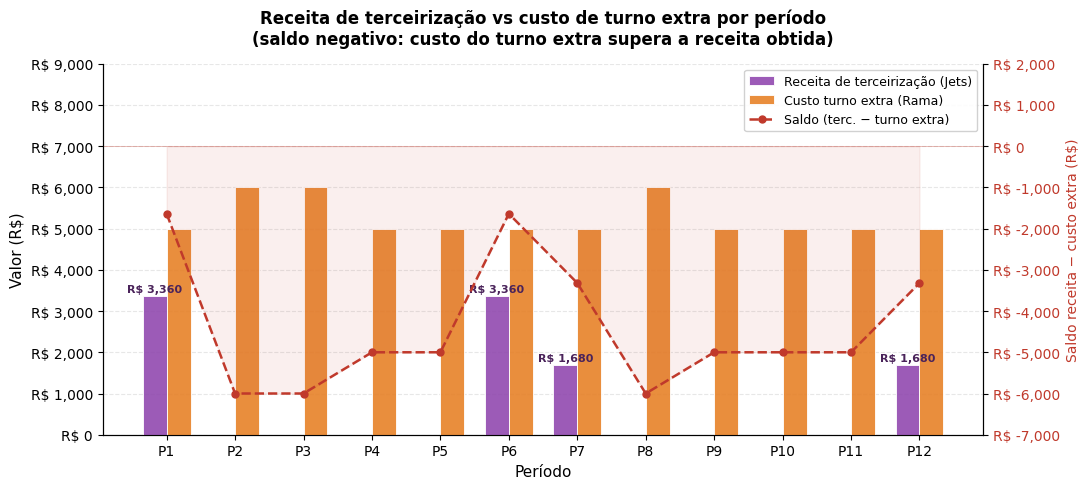

In [36]:
rec_terc    = [3360, 0, 0, 0, 0, 3360, 1680, 0, 0, 0, 0, 1680]  # receita terceirização
custo_extra = [5000, 6000, 6000, 5000, 5000, 5000, 5000, 6000, 5000, 5000, 5000, 5000]  # C.F.Turno Extra

x     = np.arange(len(periodos))
width = 0.35

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

# Barras lado a lado
b1 = ax1.bar(x - width/2, rec_terc, width,
             color='#8E44AD', alpha=0.88, edgecolor='white',
             linewidth=0.7, label='Receita de terceirização (Jets)', zorder=3)
b2 = ax1.bar(x + width/2, custo_extra, width,
             color='#E67E22', alpha=0.88, edgecolor='white',
             linewidth=0.7, label='Custo turno extra (Rama)', zorder=3)

# Rótulos nas barras de terceirização com valor
for bar, val in zip(b1, rec_terc):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, val + 60,
                 f'R$ {val:,.0f}', ha='center', va='bottom',
                 fontsize=8, color='#4A235A', fontweight='bold')

# Saldo (receita - custo extra) como linha no eixo secundário
saldo = [r - c for r, c in zip(rec_terc, custo_extra)]
ax2.plot(x, saldo, color='#C0392B', linewidth=1.8, linestyle='--',
         marker='o', markersize=5, zorder=5, label='Saldo (terc. − turno extra)')
ax2.axhline(0, color='#C0392B', linewidth=0.6, alpha=0.4)

# Faixa negativa (saldo < 0) — custo extra sempre supera receita de terc
ax2.fill_between(x, saldo, 0,
                 where=[s < 0 for s in saldo],
                 alpha=0.08, color='#C0392B', zorder=1)

# ── Eixos ─────────────────────────────────────────────────────────────────────
ax1.set_xticks(x)
ax1.set_xticklabels(periodos, fontsize=10)
ax1.set_xlabel('Período', fontsize=11)
ax1.set_ylabel('Valor (R$)', fontsize=11)
ax1.set_ylim(0, 9000)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'R$ {v:,.0f}'))
ax1.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax1.set_axisbelow(True)
ax1.spines[['top']].set_visible(False)

ax2.set_ylabel('Saldo receita − custo extra (R$)', fontsize=10, color='#C0392B')
ax2.tick_params(axis='y', labelcolor='#C0392B')
ax2.set_ylim(-7000, 2000)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'R$ {v:,.0f}'))
ax2.spines[['top']].set_visible(False)

# Legenda unificada
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='upper right', framealpha=0.9)

ax1.set_title('Receita de terceirização vs custo de turno extra por período\n'
              '(saldo negativo: custo do turno extra supera a receita obtida)',
              fontsize=12, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('grafico14_terceirizacao_extra.png', dpi=180, bbox_inches='tight')
plt.show()

##ROI


TypeError: annotate() missing 1 required positional argument: 'text'

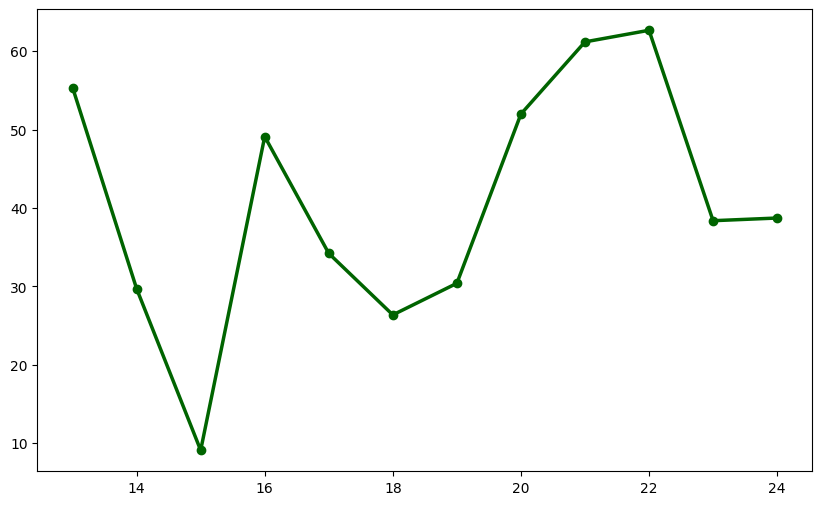

In [ ]:
# Dados financeiros fornecidos anteriormente
data = {
    'Periodo': [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
    'Rec_Vendas': [71091.0, 78003.0, 90117.0, 93438.0, 84797.0, 78835.0, 77867.5, 90373.5, 101556.5, 105877.5, 101412.0, 89000.5],
    'Custo_Total': [45757.9, 60147.1, 82622.2, 62665.8, 63187.8, 62395.0, 59723.1, 59464.0, 63005.0, 65087.4, 73291.4, 64162.7]
}

df = pd.DataFrame(data)
df['Lucro_Liquido'] = df['Rec_Vendas'] - df['Custo_Total']
df['ROI_Percentual'] = (df['Lucro_Liquido'] / df['Custo_Total']) * 100

# Gráfico de ROI
plt.figure(figsize=(10, 6))
plt.plot(df['Periodo'], df['ROI_Percentual'], color='darkgreen', marker='o', linestyle='-', linewidth=2.5, label='ROI Operacional (%)')

# Anotações para os pontos críticos
plt.annotate( xy=(15, 9.07), xytext=(13, 5),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
plt.annotate(xy=(16, 49.1), xytext=(17, 55),
             arrowprops=dict(facecolor='', shrink=0.05), fontsize=10)
plt.annotate(xy=(22, 62.6), xytext=(20, 70),
             arrowprops=dict(facecolor='pink', shrink=0.05), fontsize=10)

plt.title('Evolução do ROI Operacional ao Longo dos Períodos')
plt.xlabel('Período')
plt.ylabel('ROI (%)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig('evolucao_roi.png')

#print(df[['Periodo', 'ROI_Percentual']].to_string())